<a href="https://colab.research.google.com/github/HektorLin/out-of-stock-connect/blob/main/StockConnect_Dropouts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install yfinance
import yfinance as yf

In [ ]:
import pandas as pd
pd.set_option('display.float_format', lambda x: '%.3f' % x)
import numpy as np
import seaborn as sns
sns.set_theme(style="white", palette=None)

from datetime import datetime
from dateutil.relativedelta import relativedelta

import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
events = pd.read_csv('/content/drive/My Drive/Projects/HSI & StockConnection/Index Review Events.csv')
events['Ticker'] = events['Ticker'].astype(str).str.zfill(4) + '.HK'
events

,Date,Ticker
0,2025-03-10,0095.HK
1,2025-03-10,0410.HK
2,2025-03-10,0659.HK
3,2025-03-10,0743.HK
4,2025-03-10,1119.HK
...,...,...
152,2021-03-12,1212.HK
153,2021-03-12,1333.HK
154,2021-03-12,1788.HK
155,2021-03-12,1958.HK


## Fetching Data From Yahoo Finance

In [ ]:
events.Date.unique()

array(['2025-03-10', '2024-09-09', '2024-03-04', '2023-09-05',
       '2022-09-05', '2022-03-04', '2021-09-03', '2021-03-12'],
      dtype=object)

In [ ]:
for sdate in events.Date.unique():

    # Step1: get sdate and edate
    # Convert string to datetime object
    start_dt = datetime.strptime(sdate, '%Y-%m-%d')
    # Add 1 year and 1 month
    end_dt = start_dt + relativedelta(years=1, months=1)
    # Convert back to string
    edate = end_dt.strftime('%Y-%m-%d')

    # Step2: get stock and hsi data from yahoo
    # stock tickers to fetch
    tickers_to_fetch = [t for t in events.loc[events['Date'] == sdate, 'Ticker'].unique()]

    # To fetch multiple tickers at once
    multi_data = yf.download(tickers_to_fetch, start=sdate, end=edate, group_by='ticker')
    # Use cross-section (xs) to select 'Close' from the second level (Price)
    # axis=1 refers to columns, level=1 (or level='Price') refers to the second index layer
    # remove delisted (survivor bias in Yahoo data)
    close_prices = multi_data.xs('Close', axis=1, level=1).dropna(axis=1, how='all').ffill().bfill()

    # Fetch Hang Seng Index data
    hsi_ticker = '^HSI'
    hsi_data = yf.download(hsi_ticker, start=sdate, end=edate, group_by = 'ticker')
    hsi_prices = hsi_data.xs('Close', axis=1, level=1)

    # Step 3: turn price data into return
    price_changes = close_prices.pct_change()
    price_changes.fillna(0, inplace=True)

    hsi_changes = hsi_prices.pct_change()
    hsi_changes.fillna(0, inplace=True)

    df = price_changes.merge(hsi_changes, left_index=True, right_index=True)
    df['ref_time'] = [i+1 for i in range(-1, len(df['^HSI'])-1)]
    df = df.iloc[0:252, :]

    df.to_csv(f'/content/drive/My Drive/Projects/HSI & StockConnection/WIP/yahoo_{sdate}.csv', index=False)

/tmp/ipykernel_1192/1451215954.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  multi_data = yf.download(tickers_to_fetch, start=sdate, end=edate, group_by='ticker')
[*********************100%***********************]  28 of 28 completed
/tmp/ipykernel_1192/1451215954.py:24: FutureWarning: YF.download() has changed argument auto_adjust default to True
  hsi_data = yf.download(hsi_ticker, start=sdate, end=edate, group_by = 'ticker')
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1192/1451215954.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  multi_data = yf.download(tickers_to_fetch, start=sdate, end=edate, group_by='ticker')
[*********************100%***********************]  33 of 33 completed
/tmp/ipykernel_1192/1451215954.py:24: FutureWarning: YF.download() has changed argument auto_adjust default to True
  hsi_data = yf.download(hsi_ticker, start=sdate, end=edate, group_

## Estimate Average Event Return

In [ ]:
import glob
import os

Approach: median EW buy-and-hold market-adjusted returns

In [ ]:
# Define the folder path
folder_path = '/content/drive/My Drive/Projects/HSI & StockConnection/WIP/'

# Get a list of all csv files in the folder
csv_files = glob.glob(os.path.join(folder_path, 'yahoo_*.csv'))

print(f"Found {len(csv_files)} CSV files.")

Found 8 CSV files.


In [ ]:
# For Yahoo Data

df = pd.DataFrame()
for f in csv_files:

    sdate = f.split('_')[-1].split('.')[0]
    temp = pd.read_csv(f)

    # get stock cumulative return
    stocks = temp.iloc[:, 0:-2]
    stocks = (1 + stocks).cumprod()
    stocks = stocks.mean(axis=1)

    # get HSI cumulative reutnr
    HSI = temp['^HSI']
    HSI = (1 + HSI).cumprod()

    stocks = pd.concat([stocks, HSI], axis=1)
    stocks.columns = [sdate, 'HSI']
    stocks['diff'] = stocks[sdate] - stocks['HSI']

    df[sdate] = stocks['diff']

In [ ]:
df.iloc[0:126]

,2024-09-09,2025-03-10,2024-03-04,2022-03-04,2021-09-03,2023-09-05,2022-09-05,2021-03-12
0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,-0.107,-0.005,-0.041,0.002,-0.011,0.017,-0.005,-0.001
2,-0.121,-0.008,-0.055,-0.019,-0.023,-0.000,-0.012,0.001
3,-0.129,-0.019,-0.061,-0.020,-0.037,-0.020,0.005,0.003
4,-0.133,-0.044,-0.063,-0.034,-0.019,-0.003,-0.011,-0.010
...,...,...,...,...,...,...,...,...
121,-0.173,0.191,-0.179,0.851,0.035,-0.240,-0.034,0.093
122,-0.179,0.181,-0.177,0.886,0.038,-0.233,-0.037,0.080
123,-0.174,0.219,-0.165,1.014,0.050,-0.239,-0.046,0.096
124,-0.165,0.226,-0.157,0.843,0.049,-0.239,-0.049,0.090


In [ ]:
df = df.reset_index()
df.rename(columns = {'index':'ref_time'}, inplace = True)

In [ ]:
df = df.melt(id_vars='ref_time')
df.columns = ['ref_time', 'Event', 'CAR']

In [ ]:
df

,ref_time,Event,CAR
0,0,2024-09-09,0.000
1,1,2024-09-09,-0.107
2,2,2024-09-09,-0.121
3,3,2024-09-09,-0.129
4,4,2024-09-09,-0.133
...,...,...,...
2011,247,2021-03-12,0.069
2012,248,2021-03-12,0.062
2013,249,2021-03-12,0.048
2014,250,2021-03-12,0.049


In [ ]:
df.to_csv('temp.csv', index=False)

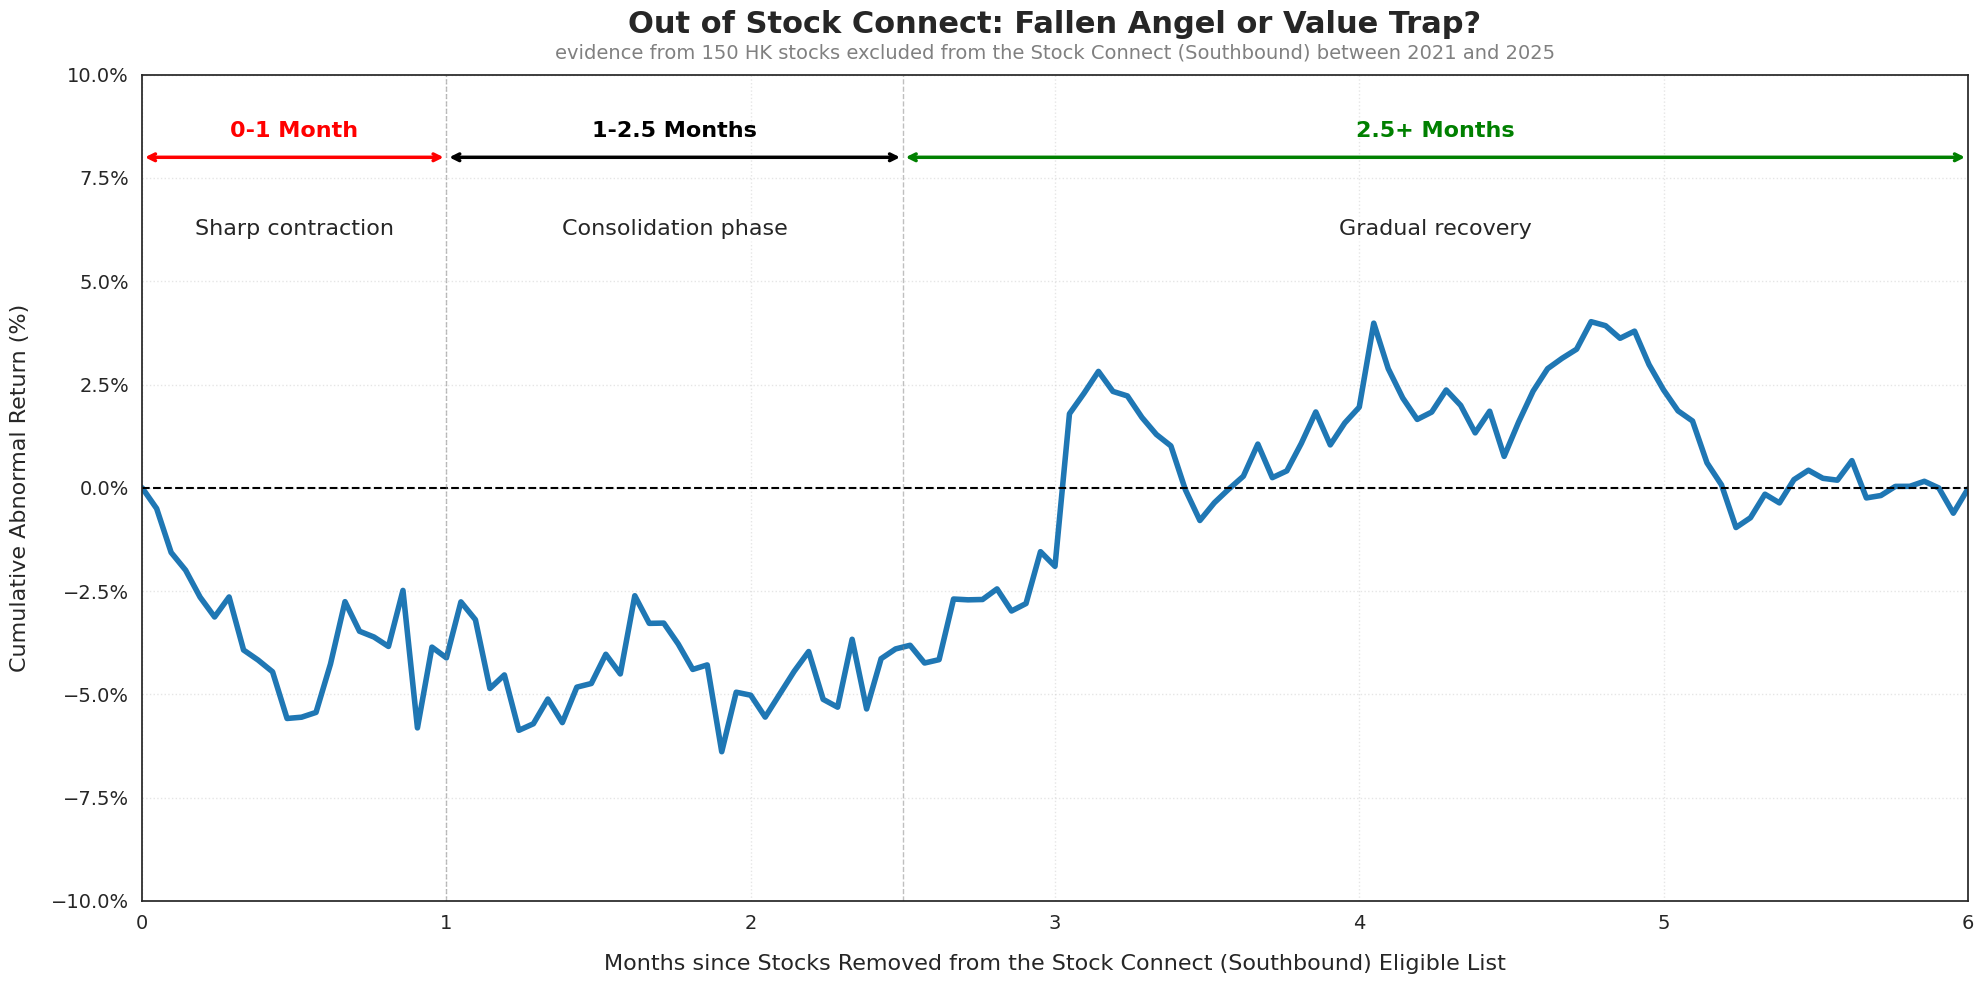

In [ ]:
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize = (20, 10))
sns.lineplot(data = df.loc[df['ref_time'] <= 126], x = 'ref_time', y = 'CAR', estimator = 'median', ax=ax, errorbar=None, linewidth=4)

# Add horizontal line at y=0
ax.axhline(0, ls='--', color='black', linewidth=1.5)

# Add vertical lines for period breaks
ax.axvline(21, ls='--', color='gray', alpha=0.5, linewidth=1)
ax.axvline(52.5, ls='--', color='gray', alpha=0.5, linewidth=1)

# Set x-ticks to intervals of 21 and format labels as int(n/21)
ax.xaxis.set_major_locator(ticker.MultipleLocator(21))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x/21)}'))
ax.tick_params(axis='both', which='major', labelsize=14)

# Format y-axis as percentage
ax.yaxis.set_major_formatter(ticker.PercentFormatter(1.0))

# Add arrows and wrapped text boxes
# Period 1
ax.annotate('', xy=(21, 0.08), xytext=(0, 0.08), arrowprops=dict(arrowstyle='<->', color='red', lw=2.5))
ax.text(10.5, 0.085, '0-1 Month', ha='center', color='red', fontsize=16, fontweight='bold')
ax.text(10.5, 0.065, 'Sharp contraction', ha='center', va='top', fontsize=16, bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

# Period 2
ax.annotate('', xy=(52.5, 0.08), xytext=(21, 0.08), arrowprops=dict(arrowstyle='<->', color='black', lw=2.5))
ax.text(36.75, 0.085, '1-2.5 Months', ha='center', color='black', fontsize=16, fontweight='bold')
ax.text(36.75, 0.065, 'Consolidation phase', ha='center', va='top', fontsize=16, bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

# Period 3
ax.annotate('', xy=(126, 0.08), xytext=(52.5, 0.08), arrowprops=dict(arrowstyle='<->', color='green', lw=2.5))
ax.text(89.25, 0.085, '2.5+ Months', ha='center', color='green', fontsize=16, fontweight='bold')
ax.text(89.25, 0.065, 'Gradual recovery', ha='center', va='top', fontsize=16, bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

# Set limits
ax.axes.set_xlim([0, 126])
ax.axes.set_ylim([-0.1, 0.1])

# Labels and grid
ax.set_title('Out of Stock Connect: Fallen Angel or Value Trap?', fontsize=22, fontweight='bold', pad=30)
ax.text(0.5, 1.02, 'evidence from 150 HK stocks excluded from the Stock Connect (Southbound) between 2021 and 2025', transform=ax.transAxes, ha='center', fontsize=14, color='gray')
ax.set_xlabel('Months since Stocks Removed from the Stock Connect (Southbound) Eligible List', fontsize=16, labelpad=15)
ax.set_ylabel('Cumulative Abnormal Return (%)', fontsize=16, labelpad=15)
ax.grid(True, which='both', linestyle=':', alpha=0.5)

plt.tight_layout()

# Save the figure with high resolution and tight margin
plt.savefig('event_study_plot.png', dpi=300, bbox_inches='tight')

plt.show()